In [1]:
import math
import torch
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append("asm_full_opt")
from phase_mask import PhaseMask
from asm_prop import ASMPropagator
from pixel_map import PixelMap
from psf_conv import PSFConv
from generate_waves_sv import GenerateWaves
from process_psf_sv import PSFProcessor
from full_opt_forward import FullOptForward
from im_postprocess import PostProcess
import config

UM = 1e-6

In [2]:
config.GRID_N = 459
config.HFOV=7
config.LENS_D=80*UM
config.PSF_WINDOW_N=275
config.SV=False

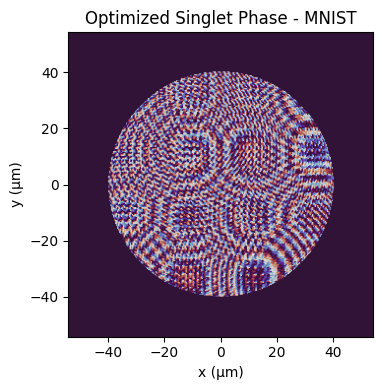

In [3]:
import os
file_path = os.path.abspath("asm_full_opt/plots/MNIST_8x7x7_phase_trained_multiplex.pt")
singlet_phase_init = torch.load(file_path, map_location="cpu")

phase = singlet_phase_init[0]

H, W = phase.shape
cH, cW = H//2, W//2
r = 155

zoom = phase[cH-r:cH+r, cW-r:cW+r]

pixel_um = 0.35
size_um = zoom.shape[0] * pixel_um
half_um = size_um / 2

plt.figure(figsize=(4,4))
plt.imshow(
    zoom.T.numpy(),
    cmap="twilight",
    origin="lower",
    extent=[-half_um, half_um, -half_um, half_um]
)

plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.title("Optimized Singlet Phase - MNIST")

plt.tight_layout()
plt.show()

Loaded batch: torch.Size([10, 28, 28])
Labels (first 10): [3, 1, 1, 0, 4, 9, 2, 0, 0, 2]


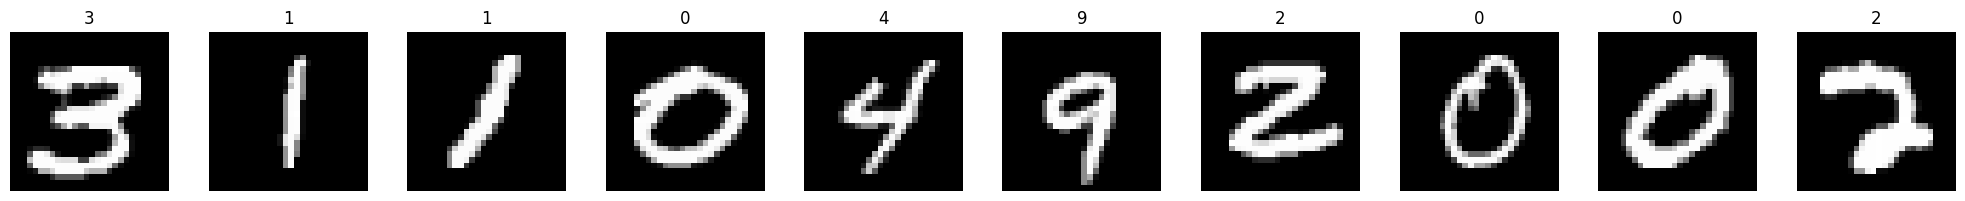

In [4]:
from torchvision.datasets import MNIST
from torchvision.datasets import FashionMNIST
ds = MNIST(root="./data", train=True, download=False)
N_batch = 10
idx0 = 111   # starting index
objs = []
labels = []
for i in range(N_batch):
    x_pil, y = ds[idx0 + i]
    objs.append(torch.from_numpy(np.array(x_pil)).float() / 255.0)
    labels.append(y)
objs = torch.stack(objs, dim=0)   
print("Loaded batch:", objs.shape)
print("Labels (first 10):", labels[:10])
fig, axes = plt.subplots(1, N_batch, figsize=(2*N_batch, 2))
for i in range(N_batch):
    axes[i].imshow(objs[i].numpy(), cmap="gray")
    axes[i].set_title(labels[i])
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [5]:
asm = ASMPropagator(config)
pm = PixelMap(config, asm.X, asm.Y)
waves = GenerateWaves(config, pm, X=asm.X, Y=asm.Y)
processor = PSFProcessor(config)
conv = PSFConv(config, pm, processor, asm.X, asm.Y)

file_path = os.path.abspath("store_outputs/MNIST_7x7_multiplex/MNIST_8x7x7_target_psf_centers.pt")
centers = torch.load(file_path, map_location="cpu")
pp = PostProcess(config, pixel_map=pm, centers=centers, X=asm.X, Y=asm.Y, mode="multiplex")

singlet_phase = PhaseMask(
    config,
    init="custom",
    custom=singlet_phase_init,
    X=asm.X,
    Y=asm.Y,    
)

imager = FullOptForward(config, singlet_phase, asm, conv, pp, pm, waves, processor)


PSF shape: torch.Size([1, 1, 459, 459])


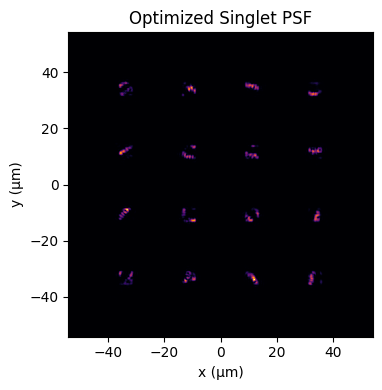

In [6]:
with torch.no_grad():
    psf, Uz = asm(phase_mask=singlet_phase, normalize=False, return_field=True)

psf0 = psf.detach().cpu()
print("PSF shape:", psf.shape)
psf = psf0[0,0]

pixel_um = 0.35

H, W = psf.shape
cH, cW = H//2, W//2
r = 155  # half window size (adjust to zoom)

zoom = psf[cH-r:cH+r, cW-r:cW+r]

half_x = (zoom.shape[1] * pixel_um) / 2
half_y = (zoom.shape[0] * pixel_um) / 2

plt.figure(figsize=(4,4))
plt.imshow(
    zoom.T,
    origin="lower",
    cmap="inferno",
    extent=[-half_x, half_x, -half_y, half_y]
)

plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.title("Optimized Singlet PSF")

plt.tight_layout()
plt.show()

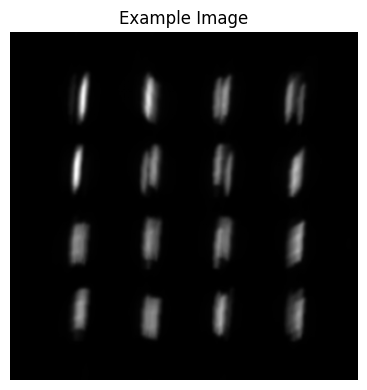

In [7]:
images = imager.optical_forward(objs)

fig, ax = plt.subplots(figsize=(4,4))

img = images[1, 0].detach().cpu().numpy().T
img = np.rot90(img, 2)

H, W = img.shape
cH, cW = H // 2, W // 2

r = 155  # half window size (adjust as needed)

zoom = img[cH-r:cH+r, cW-r:cW+r]

ax.imshow(zoom, cmap="gray", origin="lower")
ax.set_title("Example Image")
ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ---- Batched optical forward over MNIST test set ----

batch_size = 500

all_imgs = []
all_labels = []

imager.eval()
with torch.no_grad():
    for bi, i0 in enumerate(range(0, len(ds), batch_size)):
        i1 = min(i0 + batch_size, len(ds))

        # Build batch objs from dataset
        objs = []
        labels = []
        for i in range(i0, i1):
            x_pil, y = ds[i]
            objs.append(torch.from_numpy(np.array(x_pil)).float() / 255.0)
            labels.append(y)

        objs = torch.stack(objs, dim=0)   # [B,28,28]
        objs = torch.rot90(objs, k=0, dims=(-2, -1))
        labels = torch.tensor(labels)

        imgs = imager.optical_forward(objs)
        imgs = pp(imgs)

        all_imgs.append(imgs.cpu())
        all_labels.append(labels)

# Concatenate full test set
all_imgs = torch.cat(all_imgs, dim=0)
all_labels = torch.cat(all_labels, dim=0)

print("Final:")
print("all_imgs:", all_imgs.shape)
print("all_labels:", all_labels.shape)

Final:
all_imgs: torch.Size([60000, 8, 28, 28])
all_labels: torch.Size([60000])


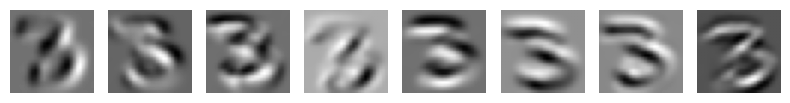

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 8, figsize=(8, 3))
for k in range(8):
    ax[k].imshow(all_imgs[12, k], cmap="gray")
    ax[k].axis("off")
plt.tight_layout()

In [10]:
import torch
import torch.nn.functional as F

feat_maps = all_imgs  

# ---- load FC weights ----
state = torch.load("asm_full_opt/plots/MNIST_8x7x7_fc_trained_multiplex.pt")
W = state["weight"]   # [10, 1152]
b = state["bias"]     # [10]


x = F.max_pool2d(feat_maps, 2)  # [N,8,12,12]
x = x.view(x.size(0), -1)  
x = F.relu(x)
logits = x @ W.t() + b     # [N,10]

# ---- accuracy ----
preds = logits.argmax(dim=1)
acc = (preds == all_labels).float().mean()

print(f"Classification accuracy: {acc.item()*100:.2f}%")

Classification accuracy: 99.00%


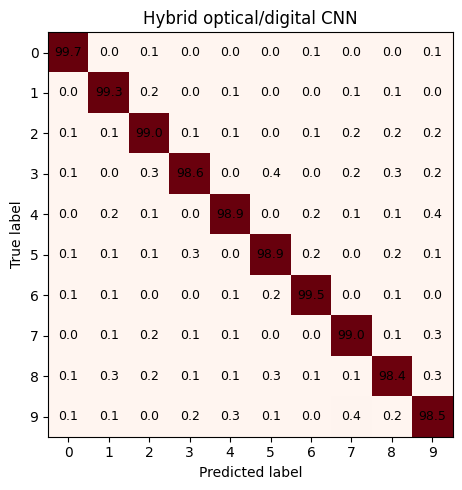

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ---- confusion matrix ----
cm = confusion_matrix(all_labels.cpu().numpy(), preds.cpu().numpy())

# convert to percentage per row
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

# ---- plot ----
fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(cm_percent, cmap="Reds")

for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{cm_percent[i,j]:.1f}",
                ha="center", va="center", fontsize=9)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Hybrid optical/digital CNN")

ax.set_xticks(range(10))
ax.set_yticks(range(10))

plt.tight_layout()
plt.show()